<a href="https://colab.research.google.com/github/swsewon3-ship-it/week2_python_panda/blob/main/Session_2_Student_Worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Session 2 — Student Worksheet (Pandas + Plotly)
Work in small groups. Find a CSV dataset on GitHub, load it in Colab, and adapt commands from the workbook.
Be ready to walk through your code at the end.


## Part 1 — Find a Dataset (GitHub)

In [10]:
# from google.colab import drive
# drive.mount('/content/drive')
#왼쪽바 폴더그림 클릭하고 마운트폴더 누르면 이게 생김
#코랩은 내 컴퓨터 파일은 못 불러오고 반드시 구글드라이브에 잇는 파일을 써야함

Mounted at /content/drive


In [ ]:
# data = /content/drive/MyDrive/Colab Notebooks/world_population_data.csv
# 이렇게 되면 이거 csv가 불러오기가 됨

In [11]:
csv = "https://raw.githubusercontent.com/venkatgmv/World-Population-Analysis-Dataset/main/world_population_data.csv"
csv

'https://raw.githubusercontent.com/venkatgmv/World-Population-Analysis-Dataset/main/world_population_data.csv'

## Part 2 — Load & Inspect

In [12]:
import pandas as pd

df = pd.read_csv(csv)
rows, cols = df.shape
rows, cols



(234, 17)

## Part 3 — Explore & Clean

In [13]:
df.dtypes

,0
rank,int64
cca3,object
country,object
continent,object
2023 population,int64
2022 population,int64
2020 population,int64
2015 population,int64
2010 population,int64
2000 population,int64


In [14]:
df.isnull().sum().sort_values(ascending=False)

,0
rank,0
cca3,0
country,0
continent,0
2023 population,0
2022 population,0
2020 population,0
2015 population,0
2010 population,0
2000 population,0


In [37]:
df['country'].value_counts()

,count
country,
India,1
China,1
United States,1
Indonesia,1
Pakistan,1
...,...
Montserrat,1
Falkland Islands,1
Niue,1


## Part 4 — Summarization

In [ ]:
category_col = 'REPLACE_ME'
numeric_col = 'REPLACE_ME'

by_cat = df.groupby(category_col)[numeric_col].sum().sort_values(ascending=False)
by_cat.head(10)

In [26]:
category_col = 'continent'
numeric_col = '2023 population'

by_continet = df.groupby(category_col)[numeric_col].sum().sort_values(ascending=False)
by_continet.head(10)

,2023 population
continent,
Asia,4751819588
Africa,1460476458
Europe,741869197
North America,604155369
South America,439719009
Oceania,45575769


In [39]:
by_country = df.groupby('country')['2023 population'].sum().sort_values(ascending=False)
by_country.head(10)

,2023 population
country,
India,1428627663
China,1425671352
United States,339996563
Indonesia,277534122
Pakistan,240485658
Nigeria,223804632
Brazil,216422446
Bangladesh,172954319
Russia,144444359


In [38]:
by_country = df.groupby('country')['2023 population'].sum().sort_values(ascending=True)
by_country.head(10)

,2023 population
country,
Vatican City,518
Tokelau,1893
Niue,1935
Falkland Islands,3791
Montserrat,4386
Saint Pierre and Miquelon,5840
Saint Barthelemy,10994
Tuvalu,11396
Wallis and Futuna,11502


## Part 5 — Visualization (Pandas + Plotly)

In [27]:
import plotly.express as px

bar_df = by_continet.head(10).reset_index()
fig = px.bar(bar_df, x=category_col, y=numeric_col, title=f'Top 10 {category_col} (interactive)')
fig.show()

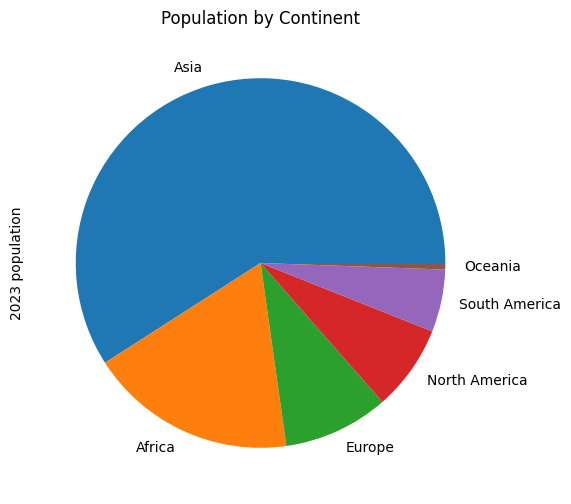

In [47]:
ax = by_continet.plot(kind='pie', y='2023 population', figsize=(12,6),
                      title='Population by Continent')

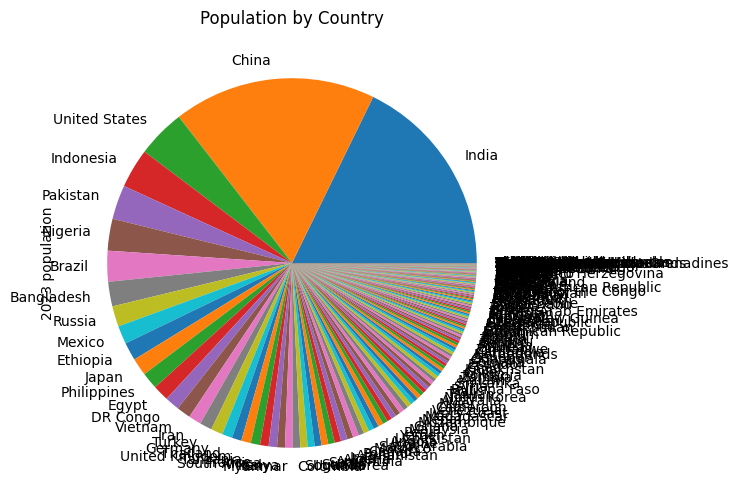

In [48]:
ax = by_country.plot(kind='pie', y='2023 population', figsize=(12,6),
                      title='Population by Country')

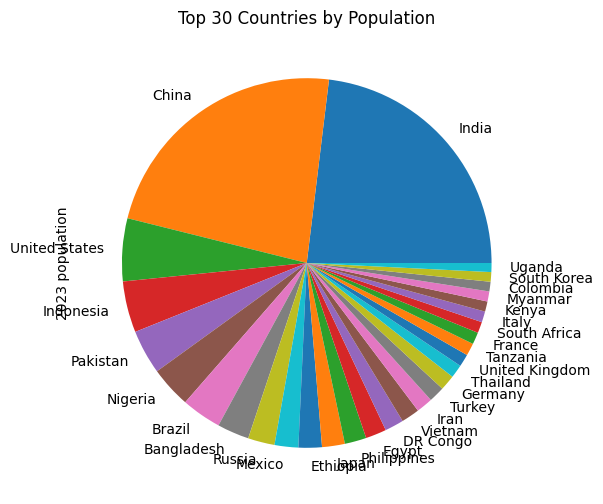

In [50]:
# 2023 population 기준으로 정렬 후 상위 30개 선택
top30 = by_country.sort_values(ascending=False).head(30)

# 파이 차트 그리기
ax = top30.plot(kind='pie',
                y='2023 population',
                figsize=(12,6),
                title='Top 30 Countries by Population')

In [53]:
import pandas as pd
import plotly.express as px

# df: 원본 데이터프레임 (질문에 준 컬럼 구조)
year_cols = ["2020 population", "2022 population", "2023 population"]

# 대륙별 합계 집계
by_continent = df.groupby("continent", dropna=False)[year_cols].sum(numeric_only=True).reset_index()

# wide → long 변환
df_long = by_continent.melt(
    id_vars="continent",
    value_vars=year_cols,
    var_name="year",
    value_name="population"
)

# "2020 population" → 2020 (int)
df_long["year"] = df_long["year"].str.extract(r"(\d{4})").astype(int)

# 라인 차트
fig = px.line(
    df_long.sort_values(["continent", "year"]),
    x="year",
    y="population",
    color="continent",
    markers=True,
    title="Population by Continent (2020–2023, available years only)"
)
fig.update_layout(xaxis=dict(dtick=1))
fig.show()

In [40]:
bar_df = by_country.head(30).reset_index()
fig = px.bar(bar_df, x='country', y=numeric_col, title=f'Bottom 10 {category_col} (interactive)')
fig.show()

In [45]:
Japan_pop = df[df["country"] == "Japan"]
print(Japan_pop)

    rank cca3 country continent  2023 population  2022 population  \
11    12  JPN   Japan      Asia        123294513        123951692   

    2020 population  2015 population  2010 population  2000 population  \
11        125244761        127250933        128105431        126803861   

    1990 population  1980 population  1970 population  area (km²)  \
11        123686321        117624196        105416839    377930.0   

    density (km²) growth rate world percentage  
11            338      -0.53%            1.54%  


## Part 6 — Reflection
- What needed adjusting when you switched datasets?
- What was easier/harder vs the workbook?
- What context/limitations should a policymaker know?


## Part 7 — ⚡ Lightning Chart Demos — Teach-Out Instructions

### What is a Lightning Demo?
A **rapid-fire mini-presentation**: 2 minutes per group. Show **one chart** + **one insight**, not your whole notebook.

### Demo Format (2 minutes)
1. **Context (15 sec):** Dataset name + 1-sentence purpose.  
2. **Chart + Insight (75–90 sec):** Show interactive Plotly chart; state one clear finding; name one wrangling step.  
3. **Caveat or Next Step (15–30 sec):** One limitation OR next idea.  
4. **Pass the mic (10 sec):** End with *“Any questions about our chart?”*

### Unique Angles
- Aggregation choice (sum vs mean, raw vs normalized).  
- Data cleaning step (conversion, deduping).  
- Encoding (bar vs line vs scatter).  
- Interactivity (facet, hover, filter).  
- Comparability (per capita vs raw counts).  
- Temporal nuance (trend vs snapshot).  

👉 If another group showed your angle, pick a different one.

### Flow for the Day
- Groups present **clustered by chart type** (bars, lines, scatter, other).  
- Instructor summarizes similarities/differences after each cluster.  
- 15 groups × 2 min = ~30 minutes + transitions = ~40 minutes.

### Presenter Checklist
- [ ] Dataset URL loads in Colab  
- [ ] Columns chosen make sense  
- [ ] One **interactive Plotly figure** with title + labels  
- [ ] Insight stated in one sentence  
- [ ] One cleaning step mentioned  

### Audience Task
After each cluster, jot 1 sentence:  
- What was **similar** across charts?  
- What was **different** (aggregation, encoding, interactivity)?  
- Which chart best supported a **policy decision**—and why?

---
### Quick Rubric (3 pts)
- **Clarity of claim (1 pt)**  
- **Method fit (1 pt)**  
- **Insight/caveat (1 pt)**  
(Bonus +0.5 for meaningful interactivity)

---
### Minimal Code Patterns

**Top-N bar:**
```python
bar_df = df.groupby(category_col)[numeric_col].sum().nlargest(10).reset_index()
fig = px.bar(bar_df, x=category_col, y=numeric_col,
             title=f"Top 10 {category_col} by {numeric_col}")
fig.show()
```

**Time series:**
```python
ts = (df.groupby(time_col)[numeric_col]
        .sum()
        .reset_index()
        .sort_values(time_col))
fig = px.line(ts, x=time_col, y=numeric_col, markers=True,
              title=f"{numeric_col} over time")
fig.show()
```

**Scatter:**
```python
fig = px.scatter(df, x=x_col, y=y_col, trendline="ols",
                 title=f"{y_col} vs {x_col}")
fig.show()
```

---